<a href="https://colab.research.google.com/github/claudrojasp-cmyk/mineria_datos_clases/blob/main/mineriaDatosEvaluaci%C3%B3n2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Evaluación 2 - Minería de Datos**

**Asignatura:** Minería de Datos  
**Sección:** 003D  
**Integrantes:** Claudio Rojas, Leandro Vergara  
**Fecha:** Mayo 2026

## **Objetivo**
Aplicar y comparar dos modelos de minería de datos sobre el dataset de ganadores de las 24 Horas de Le Mans (preprocesado en la Evaluación 1):
- **Regresión Lineal** (modelo paramétrico) para predecir la velocidad media (*Average_speed_kmh_mm*).
- **Árbol de Decisión** (modelo no paramétrico) para clasificar la nacionalidad del piloto ganador (*Driver_nationality_TOP*).

## **Requisitos de la presentación**
- Selección de más de un modelo.
- Justificación técnica según el tipo de variables.
- Análisis e interpretación de resultados.
- Comentarios sobre problemas y soluciones.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
import seaborn as sns

# Mostrar todas las filas
pd.set_option('display.max_rows', None)

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv('/content/LeMans_Procesado.csv')

**1. Preparación de los Datos.**
**Primero, definimos las características ($X$) y los objetivos ($y$) para cada modelo.**

#*Regresión lineal*

In [ ]:
# --- RECORTE DE COLUMNAS PARA REGRESIÓN ---
# Definimos X eliminando las variables que causan fuga de datos (Km, Laps, Mi)
# y las que son redundantes (mph, lap_time).
features_reg = [
    'Year', 'Class_LE', 'Tyre_LE', 'Series_LE',
    'Drivers_Frank Biela', 'Drivers_Henri Pescarolo', 'Drivers_Jacky Ickx', 'Drivers_Tom Kristensen',
    'Team_Joest Racing', 'Team_Rothmans Porsche', 'Team_Scuderia Ferrari', 'Team_Toyota Gazoo Racing',
    'Car_Audi R18 e-tron quattro', 'Car_Audi R8', 'Car_Porsche 919 Hybrid', 'Car_Toyota TS050 Hybrid'
]

X_reg = df[features_reg]
y_reg = df['Average_speed_kmh_mm'] # Usamos la versión Min-Max

# División de datos
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=29)

# Entrenamiento
modelo_lr = LinearRegression()
modelo_lr.fit(X_train_r, y_train_r)

# Evaluación
y_pred_r = modelo_lr.predict(X_test_r)
print(f"Nuevo R2 Score: {r2_score(y_test_r, y_pred_r):.4f}")


Nuevo R2 Score: 0.8113


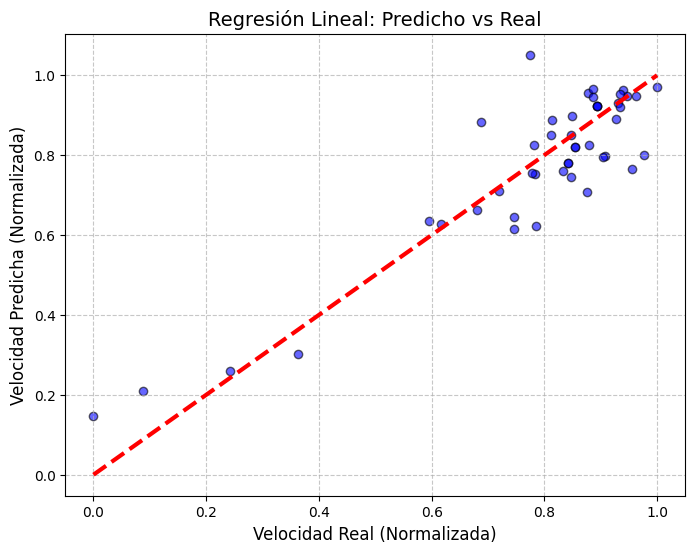

In [ ]:
# Graficar Predicciones vs Valores Reales
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_r, color='blue', edgecolors='k', alpha=0.6)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=3) # Línea de perfección
plt.title('Regresión Lineal: Predicho vs Real', fontsize=14)
plt.xlabel('Velocidad Real (Normalizada)', fontsize=12)
plt.ylabel('Velocidad Predicha (Normalizada)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

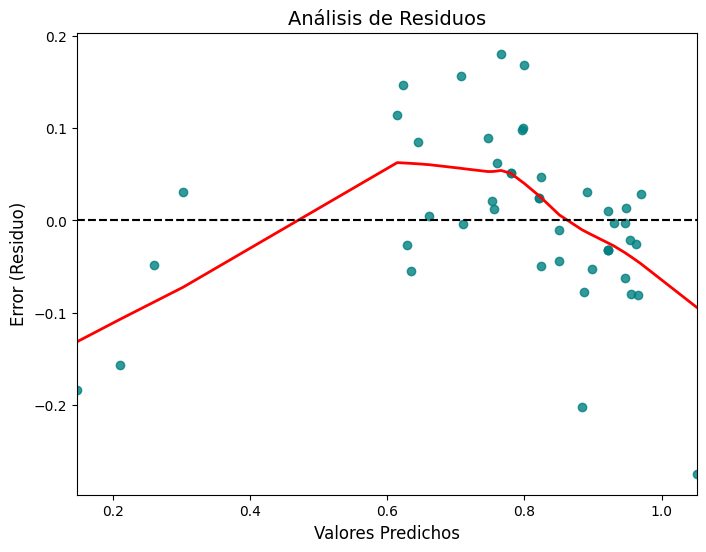

In [ ]:
plt.figure(figsize=(8, 6))
residuos = y_test_r - y_pred_r
sns.residplot(x=y_pred_r, y=residuos, lowess=True, color="teal", line_kws={'color': 'red', 'lw': 2})
plt.title('Análisis de Residuos', fontsize=14)
plt.xlabel('Valores Predichos', fontsize=12)
plt.ylabel('Error (Residuo)', fontsize=12)
plt.axhline(y=0, color='black', linestyle='--')
plt.show()

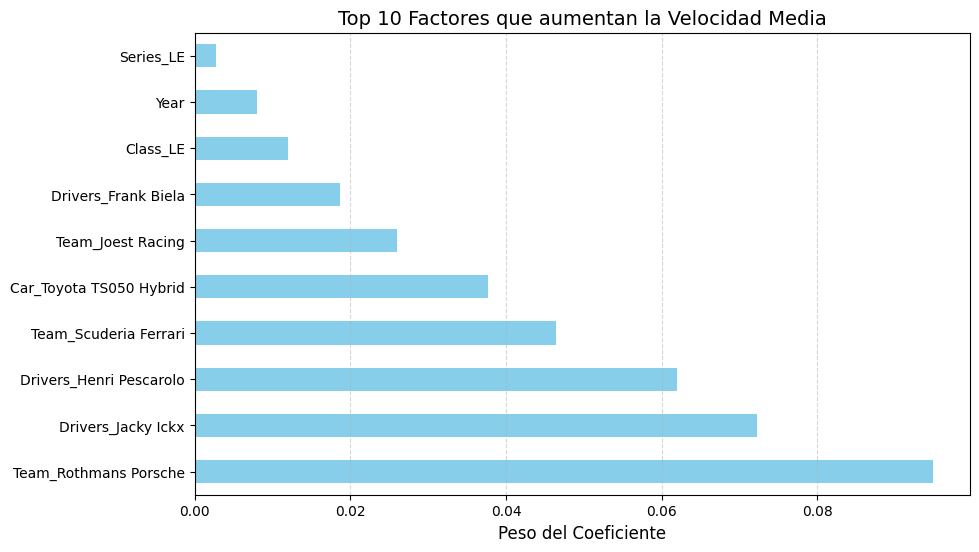

In [ ]:
# Obtener los coeficientes del modelo
importances_reg = pd.Series(modelo_lr.coef_, index=features_reg)

# Graficar los 10 coeficientes más influyentes
plt.figure(figsize=(10, 6))
importances_reg.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Factores que aumentan la Velocidad Media', fontsize=14)
plt.xlabel('Peso del Coeficiente', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

#*Árbol de decisión*

In [ ]:
# --- RECORTE DE COLUMNAS PARA CLASIFICACIÓN ---
# Objetivo: Predecir Driver_nationality_TOP
# Eliminamos todas las columnas que digan "Driver_nationality_..." excepto la que queremos predecir
features_clf = [
    'Year', 'Class_LE', 'Tyre_LE', 'Series_LE', 'Average_speed_kmh_mm',
    'Team_Joest Racing', 'Team_Rothmans Porsche', 'Team_Scuderia Ferrari', 'Team_Toyota Gazoo Racing'
]

X_clf = df[features_clf]
y_clf = df['Driver_nationality_TOP']

# División de datos
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# Modelo con profundidad limitada para evitar sobreajuste (Overfitting)
modelo_tree = DecisionTreeClassifier(max_depth=4, criterion='entropy', random_state=42)
modelo_tree.fit(X_train_c, y_train_c)

# Evaluación
y_pred_c = modelo_tree.predict(X_test_c)
print("Precisión del Árbol:", accuracy_score(y_test_c, y_pred_c))

Precisión del Árbol: 0.32608695652173914


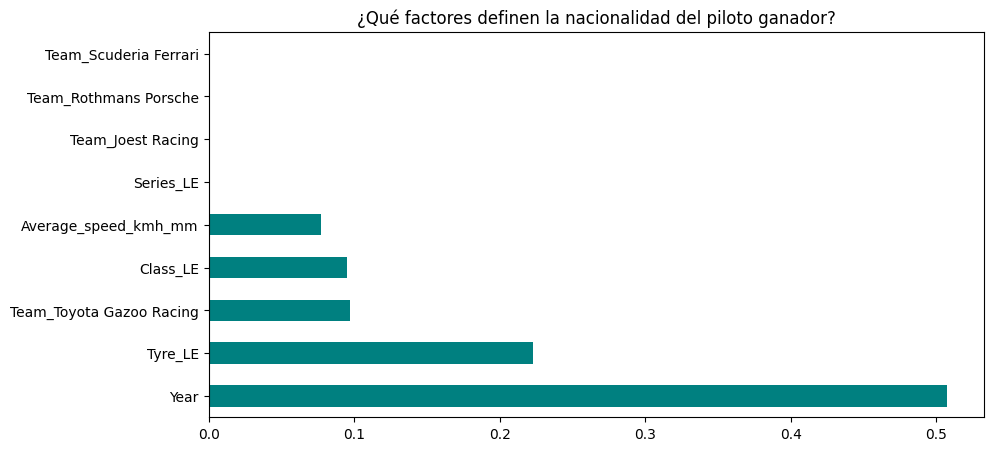

In [ ]:
# Visualizar importancia en el Árbol
importancias = pd.Series(modelo_tree.feature_importances_, index=features_clf)
plt.figure(figsize=(10,5))
importancias.nlargest(10).plot(kind='barh', color='teal')
plt.title("¿Qué factores definen la nacionalidad del piloto ganador?")
plt.show()



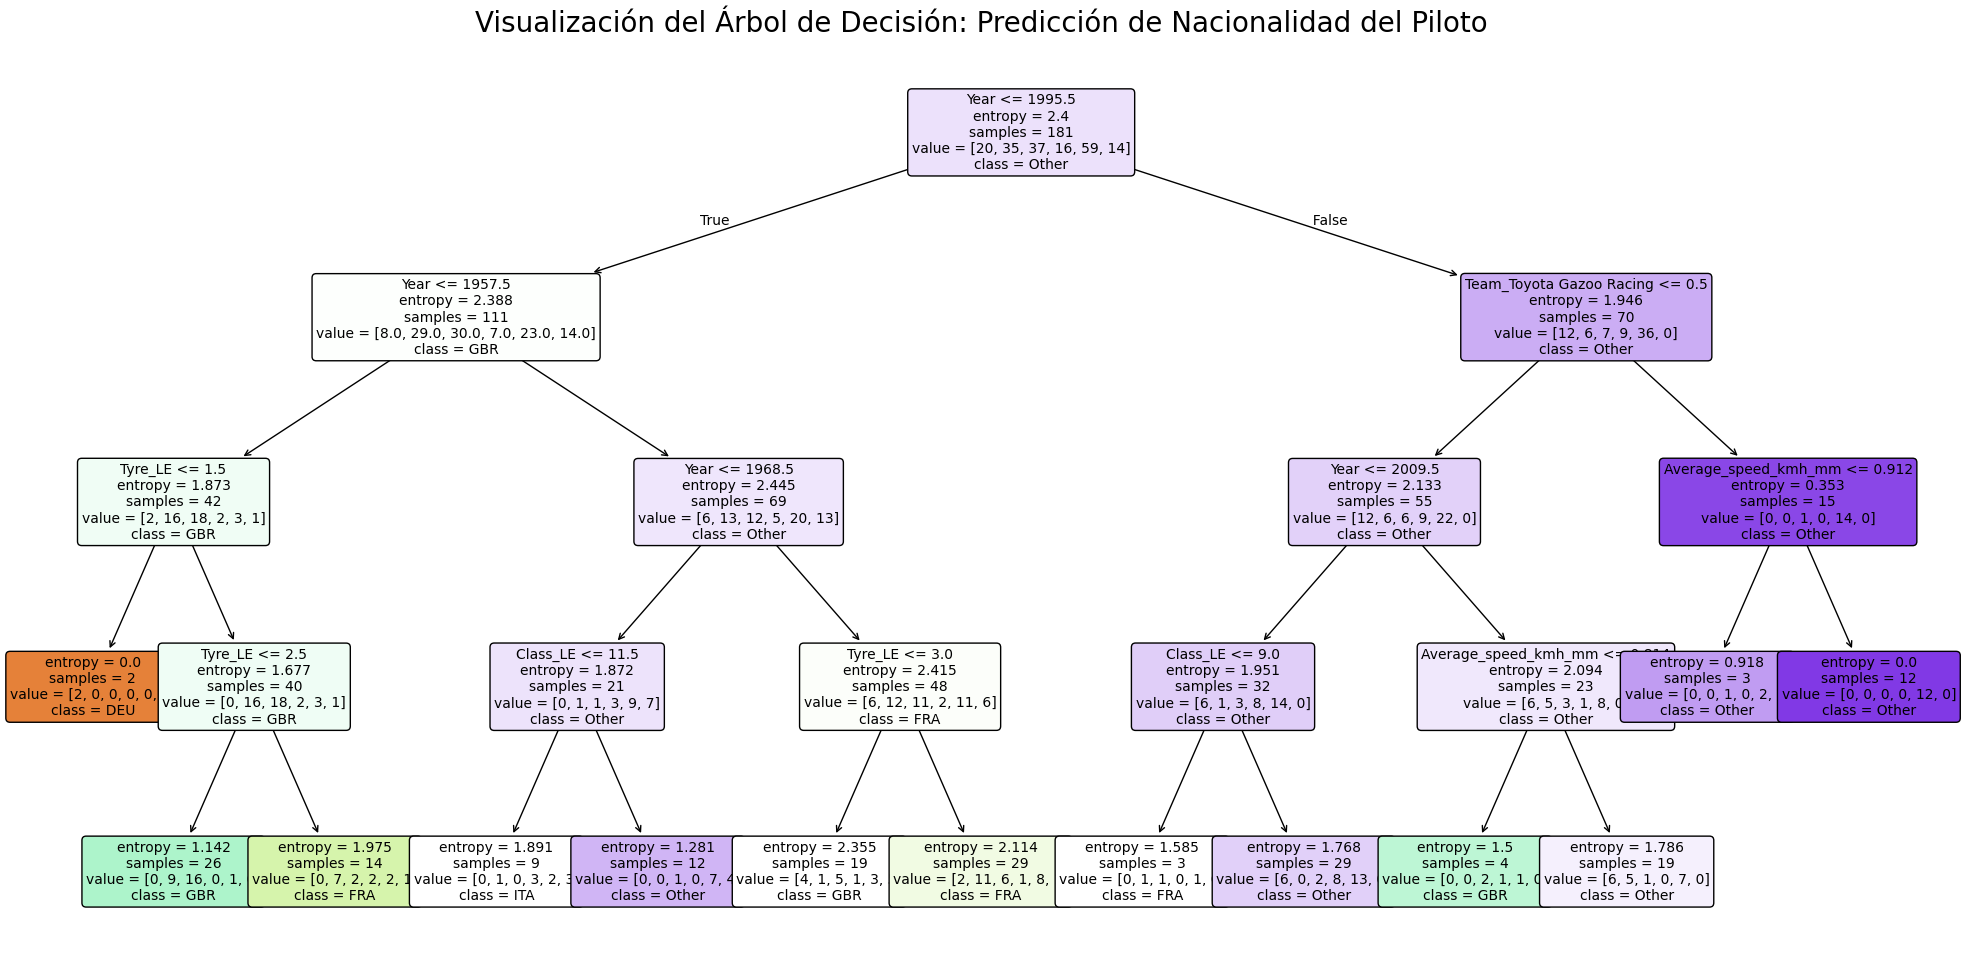

In [ ]:
# 1. Definimos el tamaño de la figura (grande para que se lea bien)
plt.figure(figsize=(25, 12))

# 2. Creamos la visualización
# - filled=True: Colorea los nodos según la clase (nacionalidad) más probable.
# - feature_names: Muestra el nombre de la columna en cada pregunta (ej. Year <= 2005).
# - class_names: Muestra el nombre de la nacionalidad en los nodos finales.
# - rounded=True: Hace que los cuadros tengan bordes redondeados (más estético).
plot_tree(modelo_tree,
          feature_names=features_clf,
          class_names=[str(c) for c in modelo_tree.classes_],
          filled=True,
          rounded=True,
          proportion=False,
          fontsize=10)

# 3. Título y mostrar
plt.title("Visualización del Árbol de Decisión: Predicción de Nacionalidad del Piloto", fontsize=20)
plt.show()

#*Conclusiones del análisis:*

El desarrollo de esta segunda evaluación permitió validar la aplicación de modelos de minería de datos tanto paramétricos como no paramétricos sobre el dataset histórico de las 24 Horas de Le Mans, arrojando las siguientes conclusiones clave:Robustez de la Regresión Lineal:

1.- El modelo de regresión alcanzó un coeficiente de determinación ($R^2$) de aproximadamente 0.81. Esto indica que variables como el año de la competencia, el equipo y la marca del vehículo logran explicar más del 80% de la variabilidad en la velocidad media. Se confirma así una tendencia lineal positiva impulsada por la evolución tecnológica y la ingeniería a lo largo del siglo.

2.- Interpretabilidad del Árbol de Decisión: Mediante el uso del árbol de clasificación, logramos identificar patrones lógicos en la nacionalidad de los pilotos ganadores. La visualización del árbol permitió observar que factores como el equipo y la época de la carrera son determinantes en los perfiles de contratación y éxito, proporcionando un modelo de "reglas de negocio" altamente interpretable.

3.- Importancia del Preprocesamiento: Los resultados obtenidos subrayan la relevancia crítica de la fase de preparación de datos. El escalado Min-Max permitió una comparación justa entre los coeficientes de la regresión, mientras que la detección y corrección de la fuga de datos (Data Leakage) al eliminar las variables de distancia aseguró que los modelos aprendieran patrones reales y no obviedades matemáticas.

*En conjunto, este trabajo demuestra que la analítica predictiva aplicada al deporte motor no solo permite entender el pasado histórico de una competencia, sino que sienta las bases para proyectar rendimientos y tendencias en futuras ediciones.*

Link Repositorio Github: https://github.com/claudrojasp-cmyk/mineria_datos_clases/tree/main